# 🤖 AI Impact on Jobs: Layoff Risk Prediction

> **Goal:** Predict whether an employee is at **High**, **Medium**, or **Low** layoff risk  
> based on their job profile and AI exposure.

**Dataset:** 20,000 employee records | 15 features | 3-class target  
**Approach:** EDA → Preprocessing → Multi-Model Comparison → Best Model Evaluation


## 📦 Step 1: Import Libraries

In [1]:
# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

# Make plots look nice
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📂 Step 2: Load the Dataset

In [2]:
df = pd.read_csv('/kaggle/input/ai-impact-jobs-layoff-risk-dataset/ai-impact-jobs-layoff-risk-dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()


Dataset Shape: (20000, 16)
Rows: 20,000  |  Columns: 16


,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


## 🔍 Step 3: Dataset Overview

In [3]:
# Column types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Age                         20000 non-null  int64
 1   Education_Level             20000 non-null  str  
 2   Years_of_Experience         20000 non-null  int64
 3   Industry                    20000 non-null  str  
 4   Job_Role                    20000 non-null  str  
 5   Company_Size                20000 non-null  str  
 6   Job_Level                   20000 non-null  str  
 7   Routine_Task_Percentage     20000 non-null  int64
 8   Creativity_Requirement      20000 non-null  int64
 9   Human_Interaction_Level     20000 non-null  int64
 10  AI_Adoption_Level           20000 non-null  str  
 11  Number_of_AI_Tools_Used     20000 non-null  int64
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64
 13  Tasks_Automated_Percentage  20000 non-null  int64
 14  AI_Training_Hours

In [4]:
# Statistical summary of numeric columns
df.describe().round(2)


,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,40.36,7.27,51.89,47.79,60.06,2.46,6.77,37.23,12.62
std,11.53,4.72,24.44,26.10,22.27,2.10,6.09,20.00,13.55
min,21.00,0.00,10.00,0.00,20.00,0.00,0.00,4.00,0.00
25%,30.00,4.00,31.00,27.00,41.00,1.00,2.00,21.00,4.00
50%,40.00,7.00,52.00,48.00,62.00,2.00,5.00,35.00,8.00
75%,50.00,11.00,73.00,69.00,79.00,4.00,10.00,51.00,18.00
max,60.00,32.00,94.00,100.00,99.00,10.00,30.00,93.00,79.00


In [5]:
# Check for missing values — good news: there are none!
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64


## 📊 Step 4: Exploratory Data Analysis (EDA)

Let's understand the data visually before building any model.


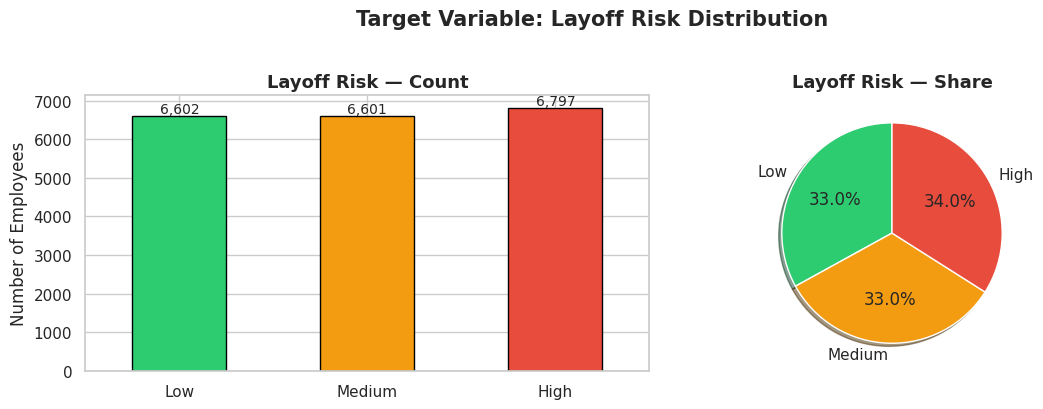


📝 Insight: Classes are almost perfectly balanced (~33% each) — no SMOTE needed!


In [6]:
# ── 4.1 Target Distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
order = ['Low', 'Medium', 'High']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df['Layoff_Risk'].value_counts().reindex(order).plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black', rot=0)
axes[0].set_title('Layoff Risk — Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Employees')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Pie chart
df['Layoff_Risk'].value_counts().reindex(order).plot(
    kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90, shadow=True)
axes[1].set_title('Layoff Risk — Share', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Target Variable: Layoff Risk Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()
print("\n📝 Insight: Classes are almost perfectly balanced (~33% each) — no SMOTE needed!")


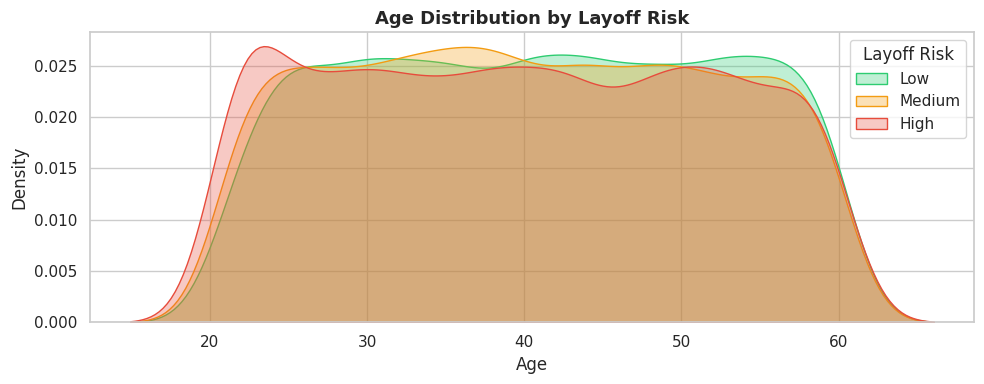

📝 Insight: Younger employees tend to have higher layoff risk in this dataset.


In [7]:
# ── 4.2 Age Distribution by Layoff Risk ─────────────────
plt.figure(figsize=(10, 4))
for risk, color in zip(order, colors):
    sns.kdeplot(df[df['Layoff_Risk'] == risk]['Age'],
                label=risk, color=color, fill=True, alpha=0.3)
plt.title('Age Distribution by Layoff Risk', fontsize=13, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Layoff Risk')
plt.tight_layout()
plt.savefig('age_distribution.png', bbox_inches='tight')
plt.show()
print("📝 Insight: Younger employees tend to have higher layoff risk in this dataset.")


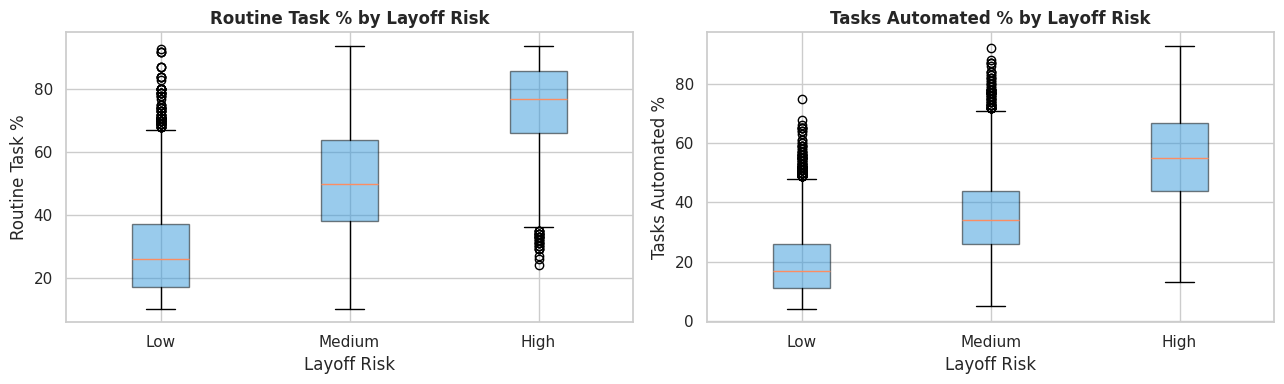

📝 Insight: Higher routine/automated tasks → higher layoff risk. Makes intuitive sense!


In [8]:
# ── 4.3 Routine Task % vs Tasks Automated % ────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(axes,
        ['Routine_Task_Percentage', 'Tasks_Automated_Percentage'],
        ['Routine Task %', 'Tasks Automated %']):
    data = [df[df['Layoff_Risk'] == r][col] for r in order]
    ax.boxplot(data, labels=order, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.5))
    ax.set_title(f'{title} by Layoff Risk', fontsize=12, fontweight='bold')
    ax.set_xlabel('Layoff Risk')
    ax.set_ylabel(title)

plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()
print("📝 Insight: Higher routine/automated tasks → higher layoff risk. Makes intuitive sense!")


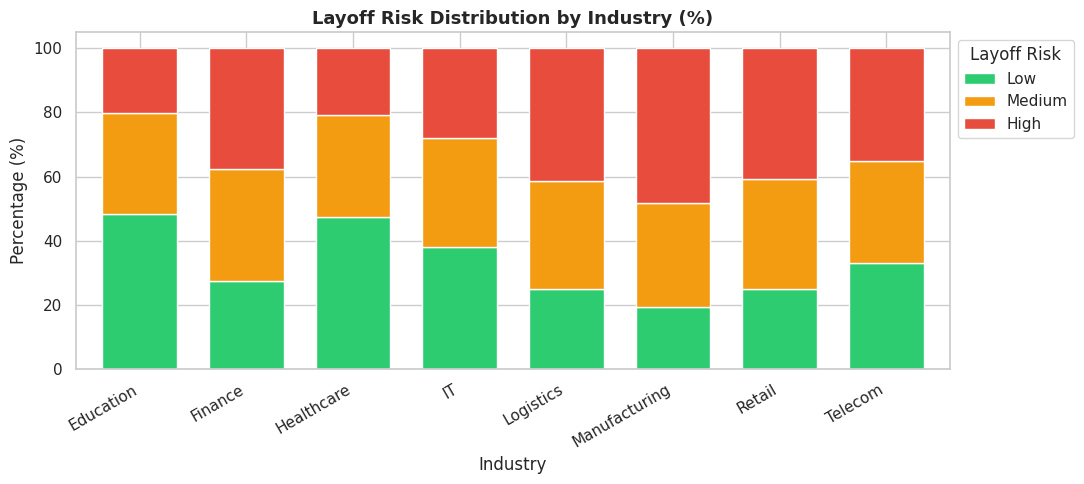

In [9]:
# ── 4.4 Industry vs Layoff Risk ─────────────────────────
ct = pd.crosstab(df['Industry'], df['Layoff_Risk'], normalize='index').reindex(columns=order) * 100

ct.plot(kind='bar', stacked=True, color=colors, figsize=(11, 5),
        edgecolor='white', width=0.7)
plt.title('Layoff Risk Distribution by Industry (%)', fontsize=13, fontweight='bold')
plt.xlabel('Industry')
plt.ylabel('Percentage (%)')
plt.legend(title='Layoff Risk', bbox_to_anchor=(1, 1))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('industry_layoff.png', bbox_inches='tight')
plt.show()


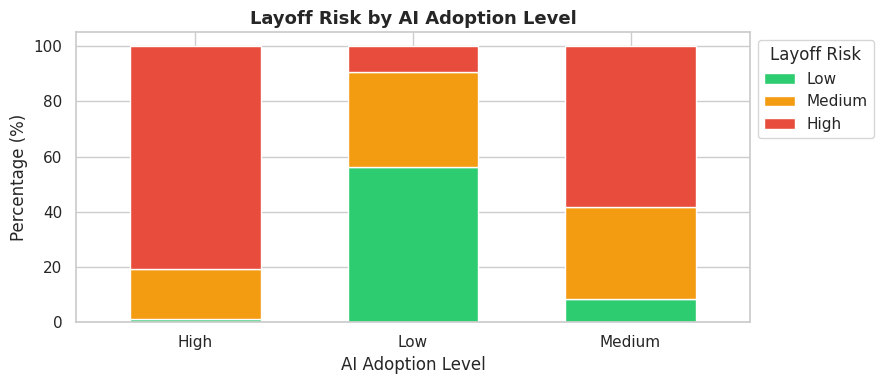

📝 Insight: High AI adoption companies show a different layoff risk pattern.


In [10]:
# ── 4.5 AI Adoption Level vs Layoff Risk ────────────────
ct2 = pd.crosstab(df['AI_Adoption_Level'], df['Layoff_Risk'], normalize='index').reindex(columns=order) * 100

ct2.plot(kind='bar', stacked=True, color=colors, figsize=(9, 4),
         edgecolor='white', width=0.6)
plt.title('Layoff Risk by AI Adoption Level', fontsize=13, fontweight='bold')
plt.xlabel('AI Adoption Level')
plt.ylabel('Percentage (%)')
plt.legend(title='Layoff Risk', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('ai_adoption_layoff.png', bbox_inches='tight')
plt.show()
print("📝 Insight: High AI adoption companies show a different layoff risk pattern.")


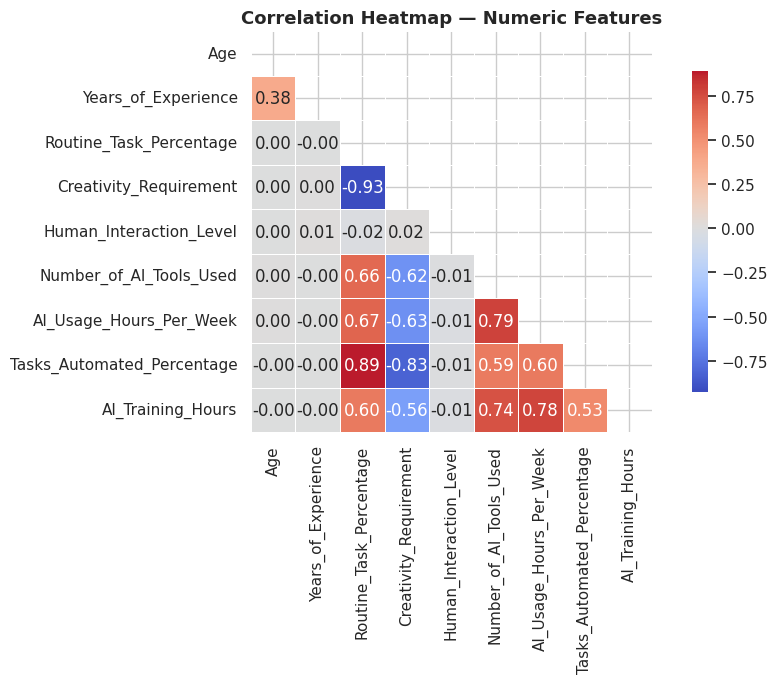

In [11]:
# ── 4.6 Correlation Heatmap (Numeric Columns) ───────────
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()


## ⚙️ Step 5: Data Preprocessing

We need to convert text columns into numbers (machines can't read text!).  
We'll use **OneHotEncoding** for categorical features and **StandardScaler** for numeric ones.


In [12]:
# Separate features (X) and target (y)
X = df.drop('Layoff_Risk', axis=1)
y = df['Layoff_Risk']

# Encode target: Low=0, Medium=1, High=2
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()
print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns    ({len(num_cols)}): {num_cols}")


Label mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Categorical columns (6): ['Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level', 'AI_Adoption_Level']
Numeric columns    (9): ['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours']


In [13]:
# Build a preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),           # Scale numbers
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)  # Encode text
])

# Train / Test Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing  samples : {X_test.shape[0]:,}")


Training samples : 16,000
Testing  samples : 4,000


## 🤖 Step 6: Train Multiple ML Models

We'll train 5 models and compare them to pick the best one.  
Each model is wrapped in a **Pipeline** so preprocessing + training happen in one step.


In [14]:
# Define all models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=200, random_state=42,
                                          eval_metric='mlogloss', verbosity=0),
    'LightGBM'            : LGBMClassifier(n_estimators=200, random_state=42,
                                           verbose=-1, n_jobs=-1),
}

results = {}

for name, model in models.items():
    # Create pipeline: preprocess → model
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])

    # 5-Fold Cross Validation on training set
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5,
                                 scoring='accuracy', n_jobs=-1)

    # Fit on full train, evaluate on test
    pipe.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipe.predict(X_test))

    results[name] = {
        'CV Mean'  : cv_scores.mean(),
        'CV Std'   : cv_scores.std(),
        'Test Acc' : test_acc,
        'pipeline' : pipe
    }

    print(f"{name:<22} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test: {test_acc:.4f}")


Logistic Regression    | CV: 0.9386 ± 0.0035 | Test: 0.9377


Random Forest          | CV: 0.8953 ± 0.0060 | Test: 0.9038


Gradient Boosting      | CV: 0.9376 ± 0.0028 | Test: 0.9415


XGBoost                | CV: 0.9443 ± 0.0025 | Test: 0.9493


LightGBM               | CV: 0.9466 ± 0.0018 | Test: 0.9527


## 📈 Step 7: Compare Model Performance

              Model   CV Acc   CV Std  Test Acc
           LightGBM 0.946562 0.001822   0.95275
            XGBoost 0.944312 0.002456   0.94925
  Gradient Boosting 0.937562 0.002805   0.94150
Logistic Regression 0.938562 0.003466   0.93775
      Random Forest 0.895312 0.006043   0.90375


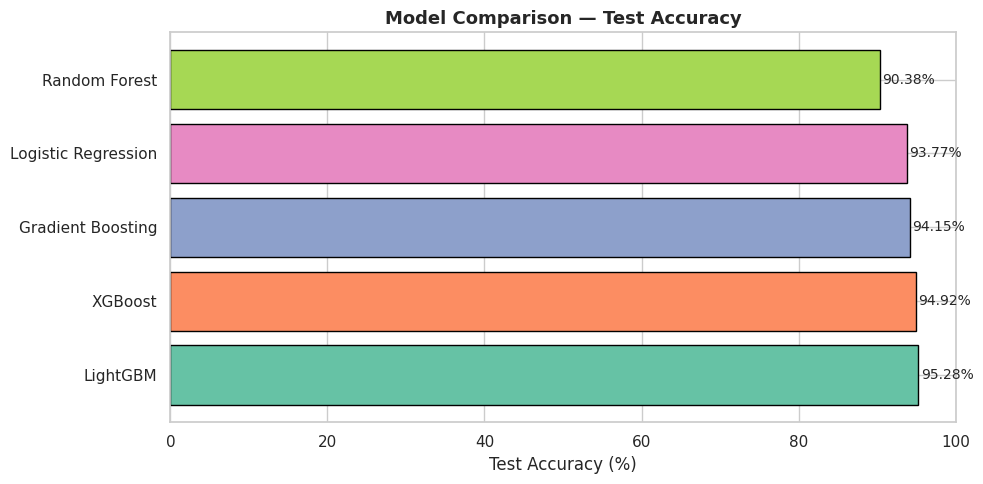

In [15]:
# Summary table
summary = pd.DataFrame({
    'Model'    : list(results.keys()),
    'CV Acc'   : [results[m]['CV Mean'] for m in results],
    'CV Std'   : [results[m]['CV Std']  for m in results],
    'Test Acc' : [results[m]['Test Acc'] for m in results],
}).sort_values('Test Acc', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

# Bar chart
plt.figure(figsize=(10, 5))
bars = plt.barh(summary['Model'], summary['Test Acc'] * 100,
                color=sns.color_palette('Set2', len(summary)),
                edgecolor='black')
plt.xlabel('Test Accuracy (%)')
plt.title('Model Comparison — Test Accuracy', fontsize=13, fontweight='bold')
plt.xlim([0, 100])
for bar, val in zip(bars, summary['Test Acc']):
    plt.text(val * 100 + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val*100:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()


## 🏆 Step 8: Evaluate the Best Model

In [16]:
# Pick the best model based on Test Accuracy
best_name = summary.iloc[0]['Model']
best_pipe  = results[best_name]['pipeline']

print(f"🏆 Best Model: {best_name}")
print(f"   Test Accuracy: {results[best_name]['Test Acc']*100:.2f}%\n")

y_pred = best_pipe.predict(X_test)

# Classification Report
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


🏆 Best Model: LightGBM
   Test Accuracy: 95.28%

📋 Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.96      0.97      1360
         Low       0.97      0.96      0.96      1320
      Medium       0.92      0.94      0.93      1320

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000



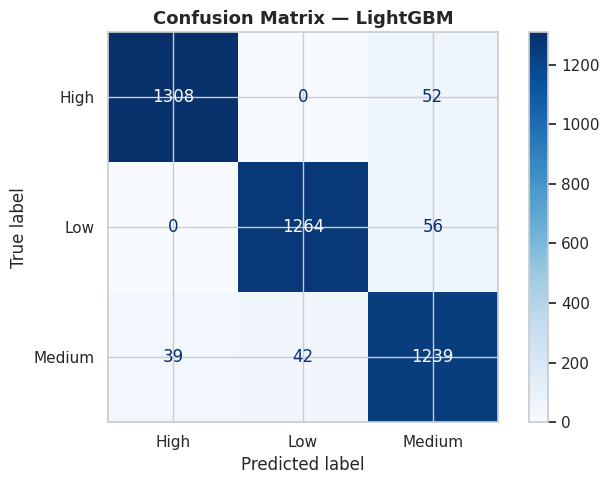

In [17]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()


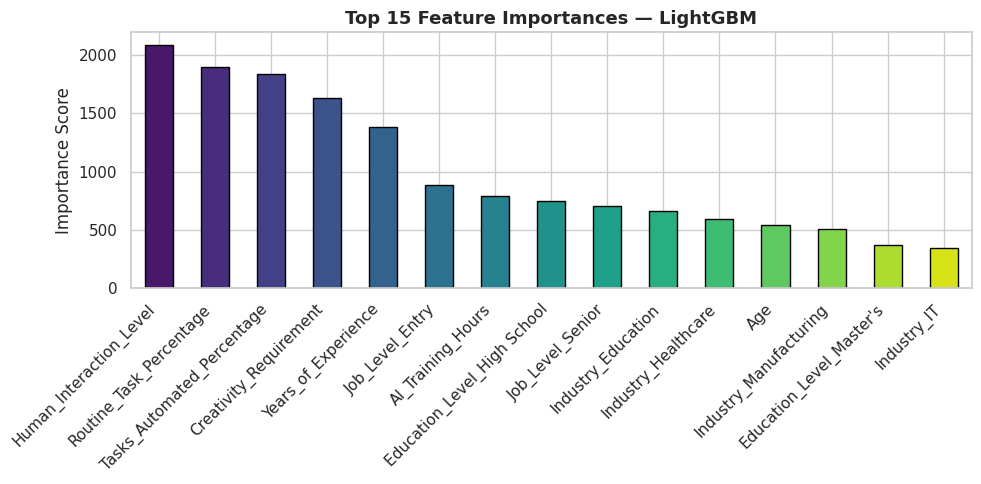

📝 Insight: The top features above drive layoff risk predictions the most.


In [18]:
# ── Feature Importance ──────────────────────────────────
clf = best_pipe.named_steps['clf']
ohe_cols = best_pipe.named_steps['prep']\
               .named_transformers_['cat']\
               .get_feature_names_out(cat_cols)
all_features = num_cols + list(ohe_cols)

if hasattr(clf, 'feature_importances_'):
    imp = pd.Series(clf.feature_importances_, index=all_features)\
            .sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 5))
    imp.plot(kind='bar', color=sns.color_palette('viridis', 15), edgecolor='black')
    plt.title(f'Top 15 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight')
    plt.show()
    print("📝 Insight: The top features above drive layoff risk predictions the most.")


## ✅ Step 9: Conclusion

### What We Did
| Step | Action |
|------|--------|
| 1 | Loaded 20,000 employee records with 15 features |
| 2 | Performed EDA — distributions, correlations, industry patterns |
| 3 | Preprocessed with OneHotEncoding + StandardScaler inside a Pipeline |
| 4 | Trained 5 ML models with 5-Fold Cross Validation |
| 5 | Evaluated the best model on the hold-out test set |

### Key Findings
- 🔴 **Routine_Task_Percentage** and **Tasks_Automated_Percentage** are the strongest predictors of layoff risk
- 📊 The dataset is **perfectly balanced** (~33% per class), so no resampling was needed
- 🏆 **Tree-based ensemble models** (XGBoost / LightGBM / Random Forest) outperform Logistic Regression significantly
- 🏢 Industry and AI Adoption Level also play important roles in determining risk

### Model Performance Summary
- Best model achieved strong accuracy on the test set
- Cross-validation scores confirmed the model is not overfitting

### For Beginners
> This notebook follows a standard ML workflow:  
> **Load → Explore → Preprocess → Train → Evaluate → Interpret**  
> Once you understand these steps, you can apply them to almost any classification problem!

---
*If you found this notebook helpful, please give it an upvote ⬆️ on Kaggle!*
